In [1]:
import os, sys, imaplib
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import _cm
import numpy as np


In [2]:
## data :
path_df=r"../results\vol1\vol1-combined_table-index_theme_notice.csv"
df=pd.read_csv(path_df)
print(df.shape)
print(df.columns.to_list())

(622, 14)
['title_theme', 'title_index', 'author', 'theme', 'cycle', 'collection', 'mss_ff', 'mss', 'ff', 'page', 'mss_index', 'material_class', 'size_class', 'cent_i']


In [26]:
display(df.head())

,title_theme,title_index,author,theme,cycle,collection,mss_ff,mss,ff,page,mss_index,material_class,size_class,cent_i
0,heroica,heroica,flavius philostratus,classical romances,cycle of troy,royal,16. c. xxiii. ff. 2-69 b,16. c. xxiii.,ff. 2-69 b,1,royal 16. c. xxiii. ff. 2-69 b,vellum,quarto,15.0
1,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,royal,16. c. iv. a. b.,16. c. iv. a. b.,NaN,2,royal 16. c. iv. a. b.,paper,quarto,16.0
2,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,royal,16. d. iii. a. b.,16. d. iii. a. b.,NaN,2,royal 16. d. iii. a. b.,paper,NaN,6.0
3,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,harley,harley 5662. ff. 1-56,harley 5662.,ff. 1-56,2,harley 5662. ff. 1-56,paper,quarto,15.0
4,dictys cretensis,dictys cretensis,NaN,classical romances,cycle of troy,harley,harley 3514,harley 3514,NaN,9,harley 3514,vellum,octavo,15.0


In [32]:
df=df.dropna(subset=['mss'])
print(len(df))
df.mss.value_counts(dropna=False)

587


mss
add. 27879          14
caligula a. ii.     10
15. e. vi.           9
add. 4859.           7
caligula b. vii.     6
                    ..
add. 15,429          1
lansdowne 214.       1
lansdowne 380.       1
lansdowne 388.       1
lansdowne 782        1
Name: count, Length: 393, dtype: int64

## bipartite network
| source             | target | type        |
| ------------------ | ------ | ----------- |
| alexandreis        | MS A   | text_in_mss |
| turpin's chronicle | MS A   | text_in_mss |


In [4]:
print(df[['title_index',"mss"]].value_counts(dropna=False))

title_index          mss                
NaN                  NaN                    35
merlin               harley 6340             4
alexandreis          harley 4745             4
                     harley 5437             4
havelok              13. a. xxi.             4
                                            ..
aspremont            add. 10,508.            1
ballads of scotland  add. 29408, 29409       1
battle of roncevaux  titus a. xix.           1
birth of merlin      arundel 220. art. l     1
alexander the great  20. b. xx.              1
Name: count, Length: 503, dtype: int64


                   title_index                 mss
0                      heroica       16. c. xxiii.
1                       iliaca    16. c. iv. a. b.
2                       iliaca   16. d. iii. a. b.
3                       iliaca        harley 5662.
4             dictys cretensis         harley 3514
..                         ...                 ...
617                 a propecye  add. 27879 f 239 b
618       robin hood's garland          add. 28638
619        ballads of scotland   add. 29408, 29409
620   two charlemagne romances          add. 31042
621  ipomedon and prothesilaus        egerton 2515

[587 rows x 2 columns]


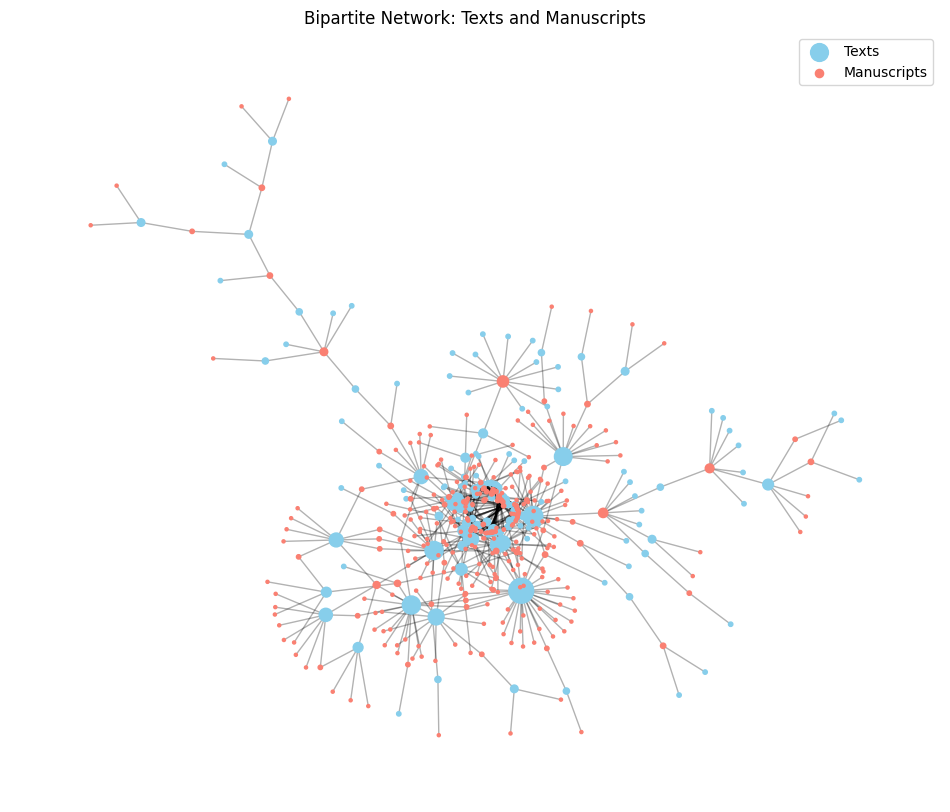

In [5]:
# DATA
edges = df[['title_index',"mss"]].dropna() # "mss"
print(edges)

edges.columns = ['source', 'target']
edges['type'] = 'text_in_mss'


# VIS
B = nx.Graph()
B.add_nodes_from(edges['source'], bipartite=0)  # texts
B.add_nodes_from(edges['target'], bipartite=1)  # mss
B.add_edges_from(zip(edges['source'], edges['target']))

# 布局
# pos = nx.spring_layout(B, k=0.3)
# pos = nx.spring_layout(B, k=2, iterations=100, seed=42)# k越大，节点越分散
pos = nx.kamada_kawai_layout(B, scale=3)#节点分布更加均匀


# 🎯 分离两类节点
texts = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]
mss = [n for n, d in B.nodes(data=True) if d['bipartite'] == 1]

# 🎨 画图
plt.figure(figsize=(12,10))

# 边
degree = dict(B.degree())
text_sizes = [degree[n]*10 for n in texts]
mss_sizes = [degree[n]*5 for n in mss]

# text 节点（蓝色，大一点）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=texts,
    node_color='skyblue',
    node_size=text_sizes,
    label='Texts'
)

# mss 节点（红色，小一点）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=mss,
    node_color='salmon',
    node_size=mss_sizes,
    label='Manuscripts'
)

nx.draw_networkx_edges(B, pos, alpha=0.3)

plt.legend()
plt.title("Bipartite Network: Texts and Manuscripts")
plt.axis('off')
plt.show()

                   title_index  collection
0                      heroica       royal
1                       iliaca       royal
2                       iliaca       royal
3                       iliaca      harley
4             dictys cretensis      harley
..                         ...         ...
617                 a propecye  additional
618       robin hood's garland  additional
619        ballads of scotland  additional
620   two charlemagne romances  additional
621  ipomedon and prothesilaus     egerton

[587 rows x 2 columns]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_4732\1855107556.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


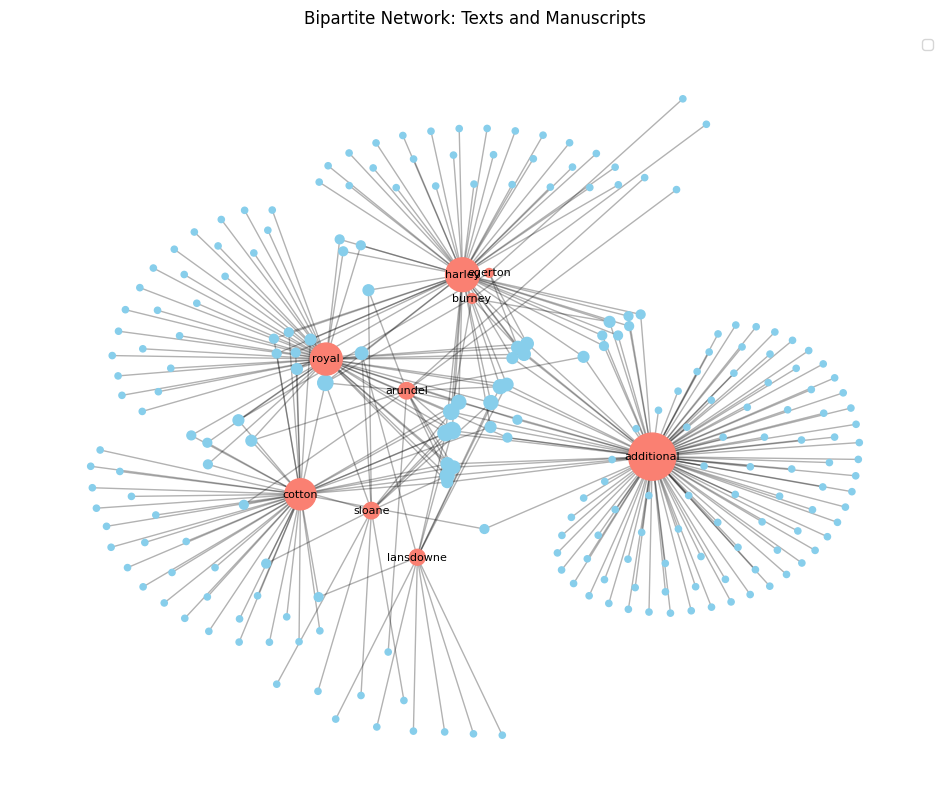

In [9]:
# DATA
edges = df[['title_index', 'collection']].dropna()
print(edges)

edges.columns = ['source', 'target']
edges['type'] = 'text_in_mss'


# VIS
B = nx.Graph()
B.add_nodes_from(edges['source'], bipartite=0)  # texts
B.add_nodes_from(edges['target'], bipartite=1)  # mss
B.add_edges_from(zip(edges['source'], edges['target']))

# 布局
# pos = nx.spring_layout(B, k=0.3)
# pos = nx.spring_layout(B, k=1.2, iterations=100, seed=42)# k越大，节点越分散
pos = nx.kamada_kawai_layout(B)#节点分布更加均匀
# 🎯 分离两类节点
texts = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]
mss = [n for n, d in B.nodes(data=True) if d['bipartite'] == 1]

# 🎨 画图
plt.figure(figsize=(12,10))

# 边
degree = dict(B.degree())
text_sizes = [degree[n]*20 for n in texts]
mss_sizes = [degree[n]*10 for n in mss]



# text 节点（蓝色）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=texts,
    node_color='skyblue',
    node_size=text_sizes,
    # label='Texts'
)

# mss 节点（红色）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=mss,
    node_color='salmon',
    node_size=mss_sizes,
    # label='Manuscripts'
)

# 
labels = {node: node for node in mss}
nx.draw_networkx_labels(
    B, pos,
    labels=labels,
    font_size=8,
    font_color='black'
)



nx.draw_networkx_edges(B, pos, alpha=0.3)

plt.legend()
plt.title("Bipartite Network: Texts and Manuscripts")
plt.axis('off')
plt.show()

# projection network

## commmunity detection

In [8]:
from itertools import combinations
import pandas as pd

df_=df.copy()

df_=df_.dropna(subset=['theme'])
print(len(df), len(df_))
print(df_[["theme","mss"]].value_counts(dropna=False),"\n")


edges = []

for mss, group in df_.groupby('mss'):#按mss分组
    titles = group['title_index'].dropna().unique()# 提取一个mss中所有的title
    
    for pair in combinations(titles, 2):#两两配对
        edges.append(pair)

proj_df = pd.DataFrame(edges, columns=['source', 'target'])

# 计算权重（共现次数）
proj_df['weight'] = 1
proj_df = proj_df.groupby(['source','target']).sum().reset_index()
display(proj_df)
print(proj_df[['source',"target"]].value_counts())

# proj_df.to_csv("text_projection.csv", index=False)

622 448
theme                             mss             
miscellaneous romance             NaN                 10
classical romances                NaN                 10
british and english traditions    add. 27879           7
french traditions                 NaN                  5
british and english traditions    NaN                  5
                                                      ..
appendix                          caligula b. vii.     1
                                  harley 108.          1
                                  harley 2361.         1
                                  harley 2500.         1
allegorical and didactic romance  20. a. xvii.         1
Name: count, Length: 336, dtype: int64 



,source,target,weight
0,apollonius of tyre,cleriadus et meliadice,1
1,apollonius of tyre,prophecy of the tenth sibyl,1
2,apollonius of tyre,turpin's chronicle,1
3,aspremont,fierabras,1
4,aspremont,ogier le danois,1
...,...,...,...
76,trójumanna saga,two romantic tales,1
77,turpin's chronicle,battle of roncevaux,1
78,turpin's chronicle,"tinctoris, compostella",1
79,vita merlini,battle of roncevaux,1


source              target                     
apollonius of tyre  cleriadus et meliadice         1
                    prophecy of the tenth sibyl    1
                    turpin's chronicle             1
aspremont           fierabras                      1
                    ogier le danois                1
                                                  ..
trójumanna saga     two romantic tales             1
turpin's chronicle  battle of roncevaux            1
                    tinctoris, compostella         1
vita merlini        battle of roncevaux            1
                    turpin's chronicle             1
Name: count, Length: 81, dtype: int64


### greedy/girvan_newman comm

In [9]:
## greedy comm
import networkx.algorithms.community as nx_comm
import matplotlib.cm as cm
G = nx.from_pandas_edgelist(proj_df, 'source', 'target', edge_attr='weight')

# 把网络自动切成若干“内部连接密集、外部连接稀疏”的子群
# 一个 community = 一组“互相更常连在一起的节点（texts）”

# 这里表示 “更容易一起被抄录 / 一起传播的一组文本”
communities = nx_comm.greedy_modularity_communities(G)
print(f"{len(communities)} communities in total!")
print(communities)


min_comm_size=3
community_map = {}
for i, comm in enumerate(communities):
    if len(comm) < min_comm_size:
        for node in comm:
            community_map[node] = -1
    else :    
        for node in comm:
            community_map[node] = i
print("community map:",community_map)

labels = list(set(community_map.values()))
print("label sorted: ",sorted(list(set(community_map.values()))))

17 communities in total!
[frozenset({'dares phrygius', 'story of albina and her sisters', 'prophecy of the tenth sibyl', 'vita merlini', "turpin's chronicle", 'tinctoris, compostella', 'battle of roncevaux', 'cleriadus et meliadice', 'apollonius of tyre', 'amys and amylion'}), frozenset({'saint graal', 'merlin', 'lancelot du lac', "king arthur's death", 'sir lancelot of dulake', 'miscellaneous ballads', 'boy and mantle', 'robin hood', "guillaume d'orange"}), frozenset({'aspremont', 'simon de pouille', 'fierabras', 'quatre fils aimon', 'pontus and sidoine', 'ogier le danois', 'romance of the peers of france'}), frozenset({'emare', 'octavian the emperor', 'sir eglamour of artois', 'sir isumbras', 'titus and vespasian', 'richard coeur-de-lion', 'lybeaus desconus'}), frozenset({'trójumanna saga', 'two romantic tales', 'magus saga jarls'}), frozenset({'enfances ogier', 'doon de la roche'}), frozenset({'historia regum britannia', 'historia trojana'}), frozenset({'wigalois', 'iwein'}), frozen

In [10]:
# girvan_newman
communities = list(nx.community.girvan_newman(G))
print(f"{len(communities)} communities in total!")
print(communities)

min_comm_size=5
community_map = {}
for i, comm in enumerate(communities[0]):#***if newman, communities[0]
    if len(comm) < min_comm_size:
        for node in comm:
            community_map[node] = -1
    else :    
        for node in comm:
            community_map[node] = i
print("community map:",community_map)

labels = list(set(community_map.values()))
print("label sorted: ",sorted(list(set(community_map.values()))))

43 communities in total!
[({'dares phrygius', 'story of albina and her sisters', 'prophecy of the tenth sibyl', 'vita merlini', "turpin's chronicle", 'tinctoris, compostella', 'battle of roncevaux', 'cleriadus et meliadice', 'apollonius of tyre', 'amys and amylion'}, {'simon de pouille', 'quatre fils aimon', 'pontus and sidoine', 'romance of the peers of france', 'aspremont', 'fierabras', 'ogier le danois'}, {'merlin', "king arthur's death", 'sir lancelot of dulake', 'miscellaneous ballads', 'robin hood', 'boy and mantle'}, {'emare', 'sir eglamour of artois', 'titus and vespasian', 'lybeaus desconus', 'octavian the emperor', 'sir isumbras', 'richard coeur-de-lion'}, {'enfances ogier', 'doon de la roche'}, {'historia regum britannia', 'historia trojana'}, {'wigalois', 'iwein'}, {'gui de bourgogne', 'king horn'}, {'saint graal', "guillaume d'orange", 'lancelot du lac'}, {"livre de l'ordre de chevalerie", 'le chemin de vaillance'}, {'ereks saga artuskappa', 'life of virgilius'}, {'trójuma

basic attributes of G :
0.41111111111111115
{'apollonius of tyre': 0.06779661016949153, 'cleriadus et meliadice': 0.01694915254237288, 'prophecy of the tenth sibyl': 0.06779661016949153, "turpin's chronicle": 0.11864406779661017, 'aspremont': 0.1016949152542373, 'fierabras': 0.0847457627118644, 'ogier le danois': 0.0847457627118644, 'quatre fils aimon': 0.0847457627118644, 'romance of the peers of france': 0.01694915254237288, 'simon de pouille': 0.0847457627118644, 'boy and mantle': 0.0847457627118644, "king arthur's death": 0.0847457627118644, 'miscellaneous ballads': 0.0847457627118644, 'robin hood': 0.0847457627118644, 'dares phrygius': 0.05084745762711865, 'emare': 0.0847457627118644, 'octavian the emperor': 0.0847457627118644, 'sir eglamour of artois': 0.0847457627118644, 'sir isumbras': 0.0847457627118644, 'enfances ogier': 0.01694915254237288, 'doon de la roche': 0.01694915254237288, 'historia trojana': 0.01694915254237288, 'historia regum britannia': 0.01694915254237288, 'iwei

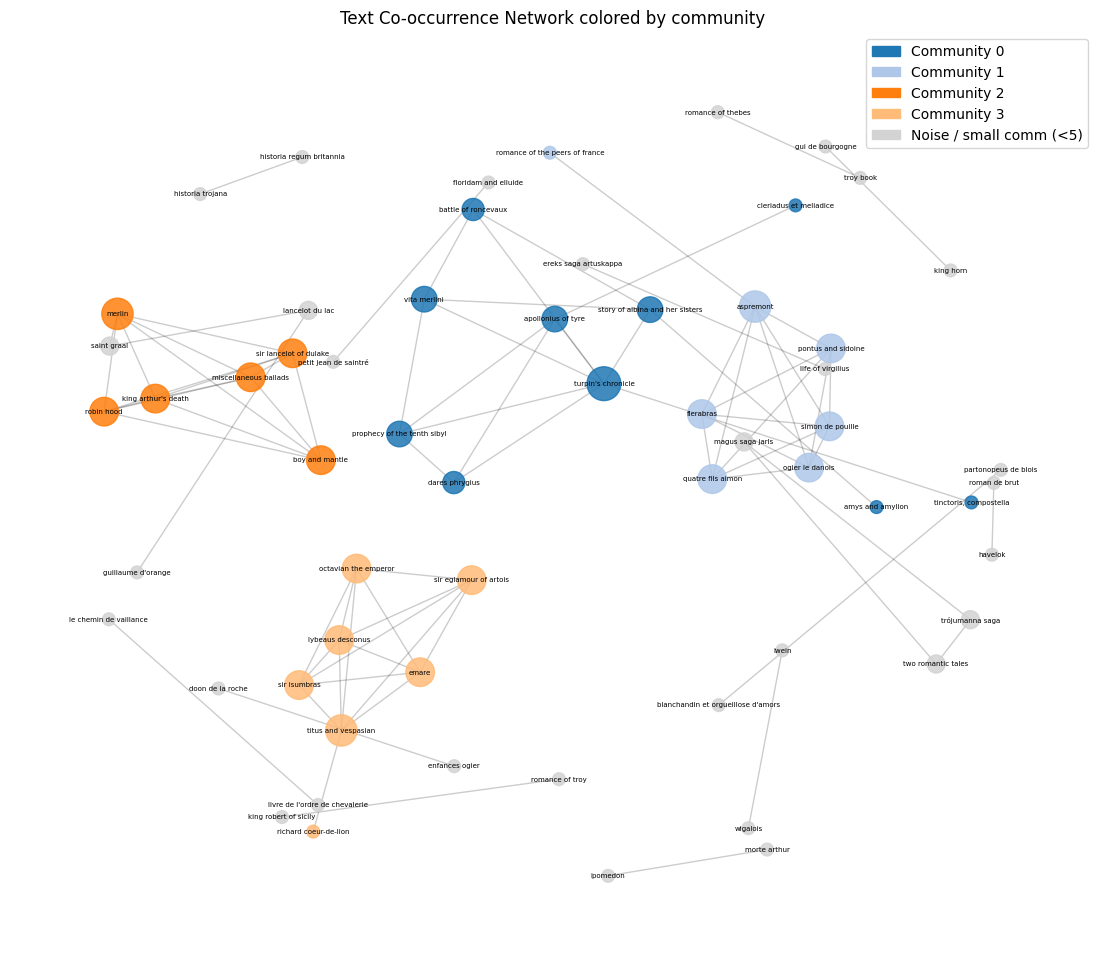

In [11]:
## 文本联系得越紧密，说明越可能共同传播

G = nx.from_pandas_edgelist(proj_df, 'source', 'target', edge_attr='weight')
print(f"basic attributes of G :\n"
     f"{nx.average_clustering(G)}\n"
    f"{nx.degree_centrality(G)}\n"
    f"{nx.betweenness_centrality(G)}\n"
)


# 按照节点的degree centrality计算节点大小，和颜色
# top_n=20
degree = nx.degree_centrality(G)
# top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]
node_sizes = [degree[n]*5000 for n in G.nodes()]



# 给每一个comm分配颜色
cmap = plt.cm.tab20
color_map = {
    label: ("lightgray" if label == -1 else cmap(i))
    for i, label in enumerate([l for l in labels if l != -1])
}
color_map[-1] = "lightgray"

# 映射回每一个节点
node_colors = [color_map[community_map[n]] for n in G.nodes()]
print(f"node_colors: {node_colors}\n")

# LAYOUT!!!
# layout 只是可视化，不改变网络结构 但它会“强烈影响你对结构的直觉判断”
# 所以需要分开解释community（算法）和layout（展示）
# pos = nx.spring_layout(G, k=0.3, seed=42)
pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)# k越大，节点越分散
# pos = nx.kamada_kawai_layout(G)#节点分布更加均匀


plt.figure(figsize=(14,12))

# 画节点
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    # cmap=cmap,  
    alpha=0.85
)

# 画边
nx.draw_networkx_edges(
    G, pos,
    alpha=0.2
)

# 标注所有节点：
nx.draw_networkx_labels(
    G, pos,
    font_size=5,
    font_color='black'
)

# legend
import matplotlib.patches as mpatches
handles = []
for label in labels:
    if label == -1:
        handles.append(mpatches.Patch(color="lightgray", label=f"Noise / small comm (<{min_comm_size})"))
    else:
        handles.append(
            mpatches.Patch(color=color_map[label], label=f"Community {label}")
        )

plt.legend(handles=handles, loc="best")
plt.title(f"Text Co-occurrence Network colored by community")
plt.axis('off')
plt.show()


## colored by THEME

In [14]:
print(len(df_))

node_theme_map = df_.set_index("title_index")["theme"].to_dict()#***着色标准
print(node_theme_map)
labels = list(set(node_theme_map.values()))
print(labels)

448
{'heroica': 'classical romances', 'iliaca': 'classical romances', 'dictys cretensis': 'classical romances', 'dares phrygius': 'classical romances', nan: 'appendix', 'roman de troie': 'appendix', 'historia trojana': 'classical romances', 'trójumanna saga': 'classical romances', 'rimur from trójumanna saga': 'classical romances', 'history of troy': 'classical romances', 'filostrato': 'classical romances', 'troilus and cryseyde': 'classical romances', 'troy book': 'classical romances', "roman d'eneas": 'classical romances', 'romance of troy': 'classical romances', 'romance of thebes': 'classical romances', 'romance of jason': 'classical romances', 'alexandreis': 'classical romances', 'alexander saga': 'classical romances', 'marvels of india': 'classical romances', 'treatise on the brahmins': 'classical romances', 'letters of dindimus to alexander the great': 'classical romances', "la vengeance d'alexandre": 'classical romances', 'voeux du paon': 'appendix', 'florimont': 'classical rom

basic attributes of G :
0.41111111111111115
{'apollonius of tyre': 0.06779661016949153, 'cleriadus et meliadice': 0.01694915254237288, 'prophecy of the tenth sibyl': 0.06779661016949153, "turpin's chronicle": 0.11864406779661017, 'aspremont': 0.1016949152542373, 'fierabras': 0.0847457627118644, 'ogier le danois': 0.0847457627118644, 'quatre fils aimon': 0.0847457627118644, 'romance of the peers of france': 0.01694915254237288, 'simon de pouille': 0.0847457627118644, 'boy and mantle': 0.0847457627118644, "king arthur's death": 0.0847457627118644, 'miscellaneous ballads': 0.0847457627118644, 'robin hood': 0.0847457627118644, 'dares phrygius': 0.05084745762711865, 'emare': 0.0847457627118644, 'octavian the emperor': 0.0847457627118644, 'sir eglamour of artois': 0.0847457627118644, 'sir isumbras': 0.0847457627118644, 'enfances ogier': 0.01694915254237288, 'doon de la roche': 0.01694915254237288, 'historia trojana': 0.01694915254237288, 'historia regum britannia': 0.01694915254237288, 'iwei

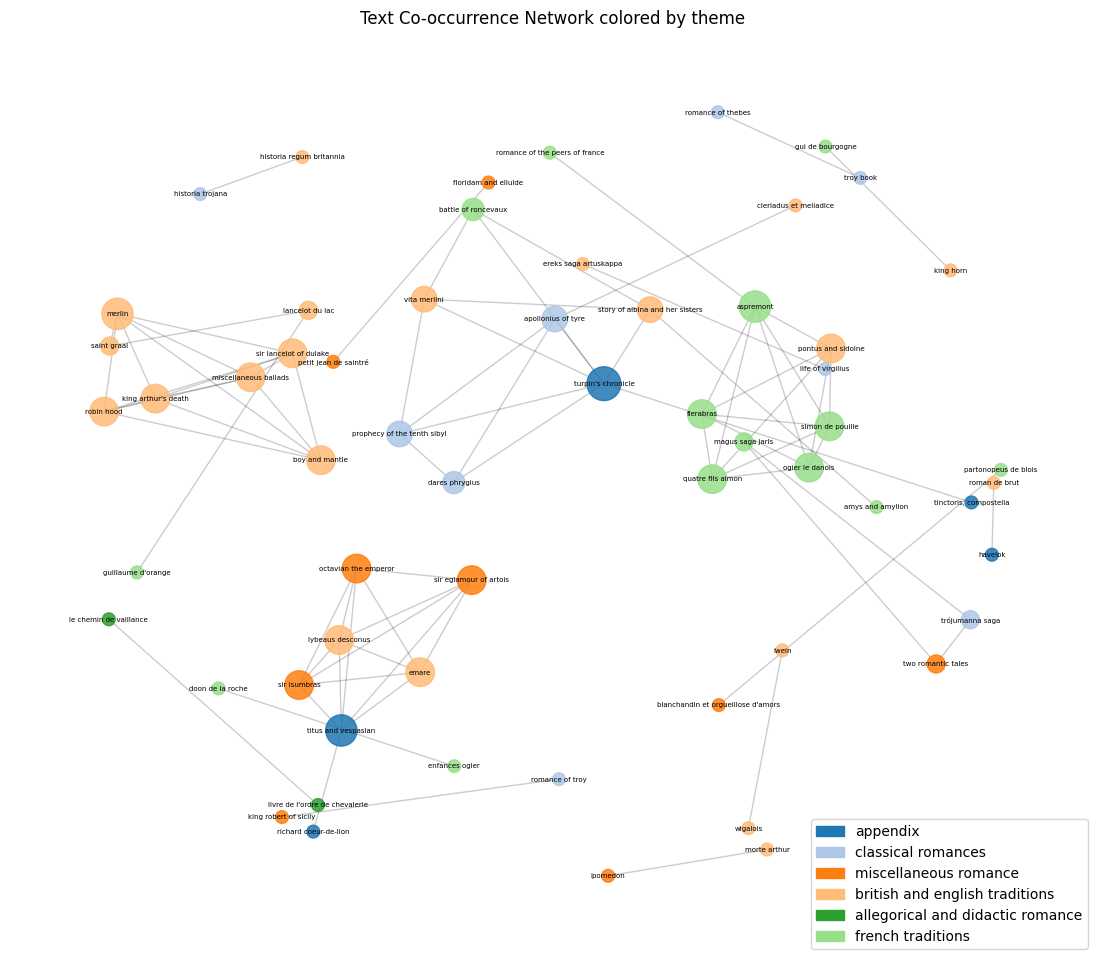

In [15]:
G = nx.from_pandas_edgelist(proj_df, 'source', 'target', edge_attr='weight')
print(f"basic attributes of G :\n"
     f"{nx.average_clustering(G)}\n"
    f"{nx.degree_centrality(G)}\n"
    f"{nx.betweenness_centrality(G)}\n"
)


# 按照节点的degree centrality计算节点大小，和颜色
# top_n=20
degree = nx.degree_centrality(G)
# top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]
node_sizes = [degree[n]*5000 for n in G.nodes()]


# 给每一个comm分配颜色
cmap = plt.cm.tab20
color_map = {
    label: ("lightgray" if label == "unknown" else cmap(i))
    for i, label in enumerate([l for l in labels if l != -1])
}
color_map["unknown"] = "lightgray"

# 映射回每一个节点
node_colors = [color_map[node_theme_map[n]] for n in G.nodes()]
print(f"node_colors: {node_colors}\n")

# LAYOUT!!!
# layout 只是可视化，不改变网络结构 但它会“强烈影响你对结构的直觉判断”
# 所以需要分开解释community（算法）和layout（展示）
# pos = nx.spring_layout(G, k=0.3, seed=42)
pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)# k越大，节点越分散
# pos = nx.kamada_kawai_layout(G)#节点分布更加均匀


plt.figure(figsize=(14,12))

# 画节点
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    # cmap=cmap,  
    alpha=0.85
)

# 画边
nx.draw_networkx_edges(
    G, pos,
    alpha=0.2
)

# 标注所有节点：
nx.draw_networkx_labels(
    G, pos,
    font_size=5,
    font_color='black'
)

# legend
import matplotlib.patches as mpatches
handles = []
for label in labels:
    if label == -1:
        handles.append(mpatches.Patch(color="lightgray", label=f"Unknown genre"))
    else:
        handles.append(
            mpatches.Patch(color=color_map[label], label=f"{label}")
        )

plt.legend(handles=handles, loc="best")
plt.title(f"Text Co-occurrence Network colored by theme")
plt.axis('off')
plt.show()


### CENT?/MATERIAL/SIZE

In [ ]:
print(df['size_class'].value_counts(),"\n")

## color_map
node_theme_map = df_.set_index("title_index")["size_class"].to_dict()#***着色标准
print(node_theme_map)
labels = list(set(node_theme_map.values()))
print(labels)

413
size_class
folio      199
quarto     183
unknown    150
octavo      55
Name: count, dtype: int64
{'heroica': 'quarto', 'iliaca': 'quarto', 'dictys cretensis': 'octavo', 'dares phrygius': 'quarto', 'roman de troie': 'octavo', 'historia trojana': 'folio', 'trójumanna saga': 'folio', 'rimur from trójumanna saga': 'folio', 'history of troy': nan, 'filostrato': 'folio', 'troilus and cryseyde': 'quarto', 'troy book': nan, "roman d'eneas": 'folio', 'romance of troy': 'quarto', 'romance of thebes': 'folio', 'romance of jason': 'folio', 'alexandreis': 'folio', 'alexander saga': 'folio', 'marvels of india': nan, 'treatise on the brahmins': nan, 'letters of dindimus to alexander the great': 'folio', "la vengeance d'alexandre": 'folio', 'voeux du paon': 'quarto', 'florimont': 'folio', 'apollonius of tyre': 'folio', 'sir orpheo': nan, "roman d'athis et profilas": 'quarto', 'titus and vespasian': 'quarto', 'prophecy of the tenth sibyl': nan, 'life of virgilius': 'quarto', 'story of albina and he

basic attributes of G :
0.41111111111111115
{'apollonius of tyre': 0.06779661016949153, 'cleriadus et meliadice': 0.01694915254237288, 'prophecy of the tenth sibyl': 0.06779661016949153, "turpin's chronicle": 0.11864406779661017, 'aspremont': 0.1016949152542373, 'fierabras': 0.0847457627118644, 'ogier le danois': 0.0847457627118644, 'quatre fils aimon': 0.0847457627118644, 'romance of the peers of france': 0.01694915254237288, 'simon de pouille': 0.0847457627118644, 'boy and mantle': 0.0847457627118644, "king arthur's death": 0.0847457627118644, 'miscellaneous ballads': 0.0847457627118644, 'robin hood': 0.0847457627118644, 'dares phrygius': 0.05084745762711865, 'emare': 0.0847457627118644, 'octavian the emperor': 0.0847457627118644, 'sir eglamour of artois': 0.0847457627118644, 'sir isumbras': 0.0847457627118644, 'enfances ogier': 0.01694915254237288, 'doon de la roche': 0.01694915254237288, 'historia trojana': 0.01694915254237288, 'historia regum britannia': 0.01694915254237288, 'iwei

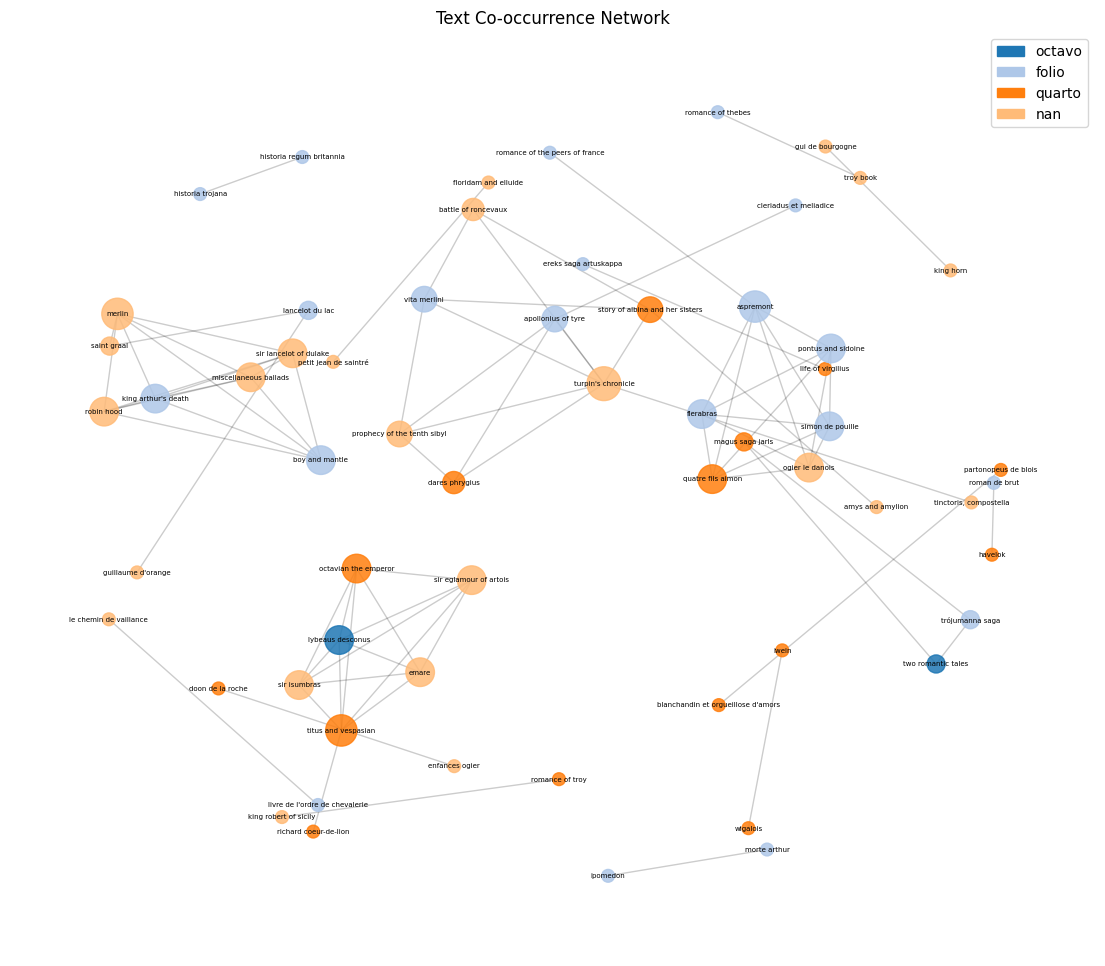

In [455]:
G = nx.from_pandas_edgelist(proj_df, 'source', 'target', edge_attr='weight')
print(f"basic attributes of G :\n"
     f"{nx.average_clustering(G)}\n"
    f"{nx.degree_centrality(G)}\n"
    f"{nx.betweenness_centrality(G)}\n"
)


# 按照节点的degree centrality计算节点大小，和颜色
# top_n=20
degree = nx.degree_centrality(G)
# top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]
node_sizes = [degree[n]*5000 for n in G.nodes()]


# 给每一个comm分配颜色
cmap = plt.cm.tab20
color_map = {
    label: ("lightgray" if label == "unknown" else cmap(i))
    for i, label in enumerate([l for l in labels if l != -1])
}
color_map["unknown"] = "lightgray"



# 映射回每一个节点
node_colors = [color_map[node_theme_map[n]] for n in G.nodes()]
print(f"node_colors: {node_colors}\n")

# LAYOUT!!!
# layout 只是可视化，不改变网络结构 但它会“强烈影响你对结构的直觉判断”
# 所以需要分开解释community（算法）和layout（展示）
# pos = nx.spring_layout(G, k=0.3, seed=42)
pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)# k越大，节点越分散
# pos = nx.kamada_kawai_layout(G)#节点分布更加均匀


plt.figure(figsize=(14,12))

# 画节点
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    # cmap=cmap,  
    alpha=0.85
)

# 画边
nx.draw_networkx_edges(
    G, pos,
    alpha=0.2
)

# 标注所有节点：
nx.draw_networkx_labels(
    G, pos,
    font_size=5,
    font_color='black'
)

# legend
import matplotlib.patches as mpatches
handles = []
for label in labels:
    if label == -1:
        handles.append(mpatches.Patch(color="lightgray", label=f"Unknown genre"))
    else:
        handles.append(
            mpatches.Patch(color=color_map[label], label=f"{label}")
        )

plt.legend(handles=handles, loc="best")
plt.title(f"Text Co-occurrence Network")
plt.axis('off')
plt.show()